## What are the most demanded skills for top 3 most popular data roles?

In [1]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
import seaborn as sns

ds = load_dataset("lukebarousse/data_jobs")                                 #loading the dataset
df = ds['train'].to_pandas()                                                #converting to dataframe type
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])               # job_posted_date cleanup

def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)
    
df['job_skills'] = df['job_skills'].apply(clean_list)                       # job_skill cleanup

In [84]:
df_ind = df[df['job_country'] == 'India']                                   # Filter Data for India

df_skills = df_ind.explode('job_skills')

df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name = 'skill_count')
df_skills_count.sort_values(by = 'skill_count', ascending = False, inplace = True)

df_skills_count

,job_skills,job_title_short,skill_count
1374,sql,Data Engineer,12993
1088,python,Data Engineer,11568
1089,python,Data Scientist,9248
1327,spark,Data Engineer,7157
103,aws,Data Engineer,6993
...,...,...,...
389,esquisse,Data Scientist,1
887,node.js,Senior Data Analyst,1
753,matlab,Cloud Engineer,1
411,fastapi,Cloud Engineer,1


In [85]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])                                          # Keeps only top 3 in the list (based on the order they appear in DataFrame)
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

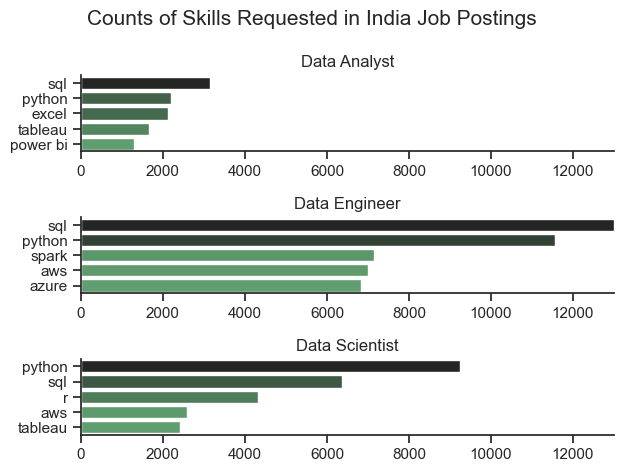

In [88]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    sns.barplot(data = df_plot, x = 'skill_count', y = 'job_skills', ax = ax[i], hue = 'skill_count', palette = 'dark:g_r', legend = False)
    sns.despine()
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 13000)
fig.suptitle('Counts of Skills Requested in India Job Postings', fontsize=15)
fig.tight_layout()
plt.show()
    